In [1]:
# ===============================
# 1. IMPORT LIBRARIES
# ===============================
import cv2
import torch
import torchvision
import numpy as np
from PIL import Image
from tqdm import tqdm
import torch.nn as nn
import torch.optim as optim
from google.colab import files
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from transformers import T5Tokenizer, T5ForConditionalGeneration
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay



# ===============================
# 2. DEVICE CONFIGURATION
# ===============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ===============================
# 3. MOUNT GOOGLE DRIVE
# ===============================
from google.colab import drive
drive.mount('/content/drive')

# ===============================
# 4. DATASET PATHS
# ===============================
train_dir = "/content/drive/MyDrive/tomato_datasets/train"
val_dir   = "/content/drive/MyDrive/tomato_datasets/val"
test_dir  = "/content/drive/MyDrive/tomato_datasets/test"




Using device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:

# ===============================
# 5. IMAGE TRANSFORMS
# ===============================
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])



# ===============================
# 6. DATASET & DATALOADERS
# ===============================
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset   = datasets.ImageFolder(val_dir, transform=val_transforms)
test_dataset  = datasets.ImageFolder(test_dir, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))
print("Test samples:", len(test_dataset))


Classes: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']
Train samples: 7029
Val samples: 1500
Test samples: 1500


In [3]:
# ===============================
# 7. MODEL: RESNET-18
# ===============================
num_classes = 10
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

# ===============================
# 8. LOSS, OPTIMIZER, SCHEDULER
# ===============================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

# ===============================
# 9. TRAINING FUNCTION
# ===============================
def train_one_epoch(model, loader):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / len(loader)
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy

# ===============================
# 10. VALIDATION FUNCTION
# ===============================
def evaluate(model, loader):
    model.eval()
    running_loss = 0.0
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validation", leave=False):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = running_loss / len(loader)
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy



/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [4]:
# ===============================
# 11. TRAINING LOOP
# ===============================
num_epochs = 15
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    print(f"\nEpoch [{epoch+1}/{num_epochs}]")

    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc = evaluate(model, val_loader)

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )

# ===============================
# 13. TEST EVALUATION
# ===============================
test_loss, test_acc = evaluate(model, test_loader)

print(
    f"\nTest Loss: {test_loss:.4f} | "
    f"Test Accuracy: {test_acc:.2f}%"
)


# ===============================
# 12. SAVE MODEL
# ===============================
model_path = "/content/drive/MyDrive/tomato_datasets/tomato_disease_detection_vlm_1.pth"
torch.save(model.state_dict(), model_path)
print("\nModel saved at:", model_path)



Epoch [1/15]


Train Loss: 0.4102 | Train Acc: 87.75% | Val Loss: 0.0878 | Val Acc: 97.47%

Epoch [2/15]


Train Loss: 0.1047 | Train Acc: 96.77% | Val Loss: 0.0556 | Val Acc: 98.40%

Epoch [3/15]


Train Loss: 0.0635 | Train Acc: 98.11% | Val Loss: 0.0527 | Val Acc: 98.53%

Epoch [4/15]


Train Loss: 0.0454 | Train Acc: 98.79% | Val Loss: 0.0330 | Val Acc: 98.87%

Epoch [5/15]


...

Train Loss: 0.0082 | Train Acc: 99.82% | Val Loss: 0.0125 | Val Acc: 99.40%

Epoch [13/15]


Train Loss: 0.0081 | Train Acc: 99.82% | Val Loss: 0.0120 | Val Acc: 99.53%

Epoch [14/15]


Train Loss: 0.0057 | Train Acc: 99.90% | Val Loss: 0.0129 | Val Acc: 99.60%

Epoch [15/15]


Train Loss: 0.0069 | Train Acc: 99.86% | Val Loss: 0.0116 | Val Acc: 99.67%



Test Loss: 0.0159 | Test Accuracy: 99.60%

Model saved at: /content/drive/MyDrive/tomato_datasets/tomato_disease_detection_vlm_1.pth


In [5]:

# ===============================
# 13. LEAF SEGMENTATION
# ===============================
def segment_leaf(image_path):
    """
    Segment tomato leaf from background using HSV color thresholding.
    Returns segmented PIL image.
    """
    # Read image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Convert to HSV
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

    # Green color range for leaves
    lower_green = np.array([25, 40, 40])
    upper_green = np.array([85, 255, 255])

    # Create mask
    mask = cv2.inRange(hsv, lower_green, upper_green)

    # Morphological cleanup
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    # Apply mask
    segmented = cv2.bitwise_and(image, image, mask=mask)

    return Image.fromarray(segmented)


class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_backward_hook(backward_hook)

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[0, class_idx].backward()

        # Global Average Pooling
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1)

        cam = F.relu(cam)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() + 1e-8)

        return cam

def show_gradcam(image_path, model):
    # Load and preprocess image
    image = Image.open(image_path).convert("RGB")
    input_tensor = val_transforms(image).unsqueeze(0).to(device)

    # Initialize Grad-CAM on last conv layer
    gradcam = GradCAM(model, model.layer4[-1].conv2)
    cam = gradcam.generate(input_tensor)

    # Resize CAM to image size
    cam = cv2.resize(cam, image.size)

    # Overlay heatmap
    heatmap = cv2.applyColorMap(
        np.uint8(255 * cam), cv2.COLORMAP_JET
    )
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    overlay = np.array(image) * 0.6 + heatmap * 0.4
    overlay = overlay.astype(np.uint8)

    plt.figure(figsize=(6, 6))
    plt.imshow(overlay)
    plt.axis("off")
    plt.title("Grad-CAM: Disease-Affected Regions")
    plt.show()


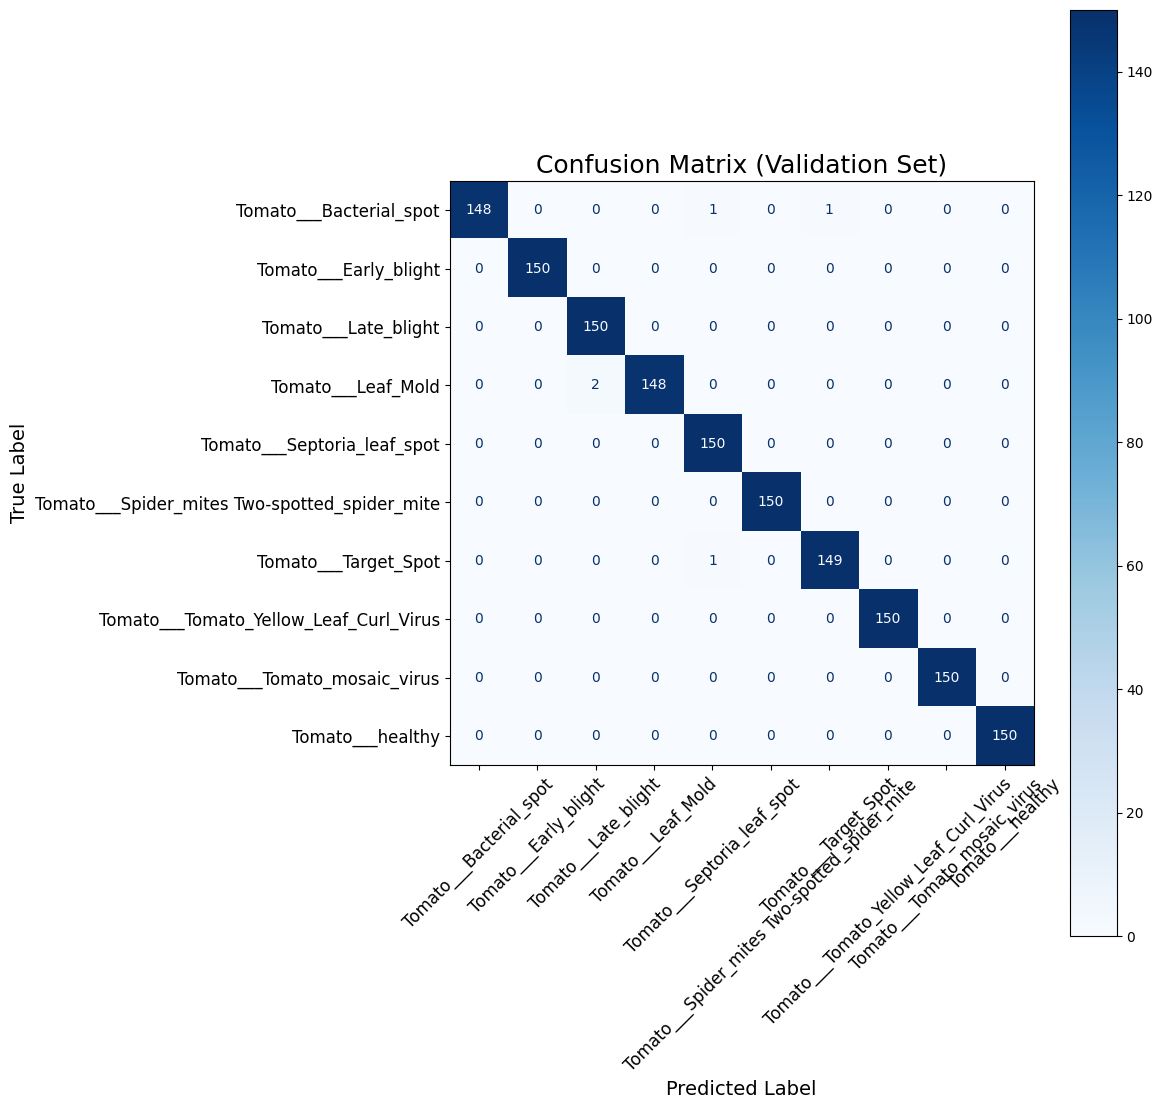

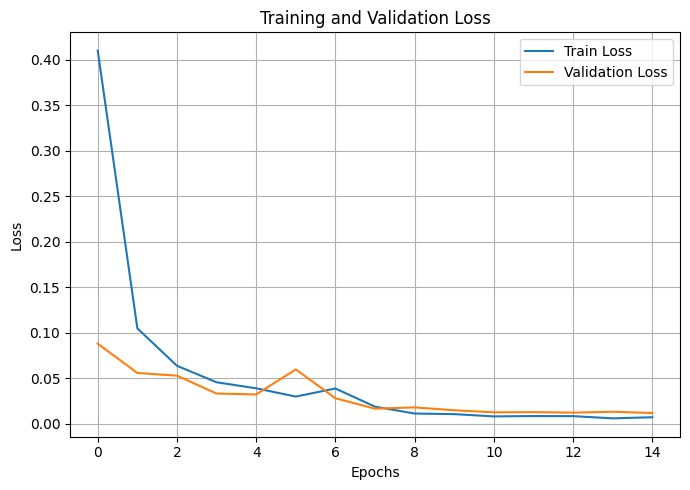

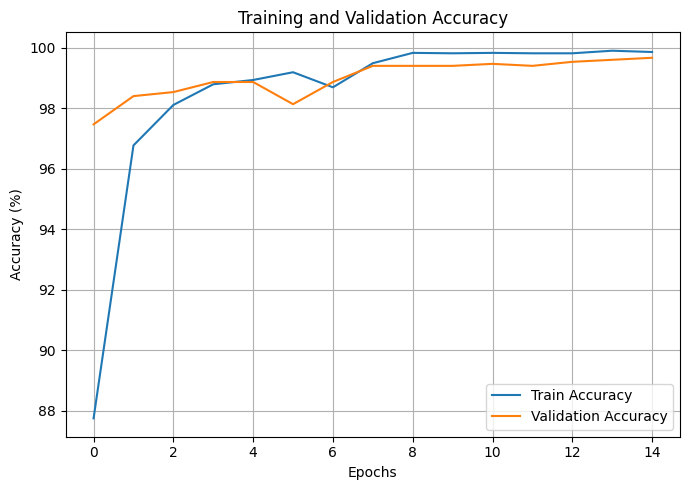

In [6]:
# ===============================
# 14. CONFUSION MATRIX
# ===============================

y_true, y_pred = [], []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(1).cpu().numpy()

        y_pred.extend(preds)
        y_true.extend(labels.numpy())

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# ===============================
# PLOT AND SAVE HIGH-RES CONFUSION MATRIX
# ===============================
plt.figure(figsize=(12, 12))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(
    include_values=True,
    cmap="Blues",
    ax=plt.gca(),
    xticks_rotation=45,
    values_format="d"
)

plt.title("Confusion Matrix (Validation Set)", fontsize=18)
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)

# Adjust font sizes for tick labels
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()

# Save locally with high resolution
plt.savefig("confusion_matrix_highres.png", dpi=600)
plt.show()


# ===============================
# TRAIN vs VALIDATION LOSS
# ===============================
plt.figure(figsize=(7, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save figure
plt.savefig("train_val_loss.png", dpi=300)
plt.show()

# ===============================
# TRAIN vs VALIDATION ACCURACY
# ===============================
plt.figure(figsize=(7, 5))
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save figure
plt.savefig("train_val_accuracy.png", dpi=300)
plt.show()

In [7]:
# ===============================
# 15. LOAD FLAN-T5 (TEXT GENERATION MODEL)
# ===============================
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
LLM_MODEL_NAME = "google/flan-t5-large"
tokenizer = AutoTokenizer.from_pretrained(LLM_MODEL_NAME)
t5_model = AutoModelForSeq2SeqLM.from_pretrained(LLM_MODEL_NAME).to(device)

print("✅ FLAN-T5-large loaded")

# ===============================
# 16. DISEASE HINTS (FOR LLM)
# ===============================
DISEASE_HINTS = {
    "Tomato___Bacterial_spot": "small dark water-soaked spots on leaves",
    "Tomato___Early_blight": "concentric rings and yellowing leaves",
    "Tomato___Late_blight": "rapidly spreading dark lesions",
    "Tomato___Leaf_Mold": "yellow patches with mold growth underneath",
    "Tomato___Septoria_leaf_spot": "small circular spots with gray centers",
    "Tomato___Spider_mites Two-spotted_spider_mite": "stippling and webbing",
    "Tomato___Target_Spot": "brown target-like lesions",
    "Tomato___Tomato_mosaic_virus": "mosaic patterns and leaf distortion",
    "Tomato___Tomato_Yellow_Leaf_Curl_Virus": "leaf curling and yellowing"
}

# ===============================
# 17. HARDCODED DISEASE ADVICE
# ===============================
disease_info = {
    "Tomato___Bacterial_spot": "Apply copper fungicide and remove infected leaves.",
    "Tomato___Early_blight": "Reduce irrigation and apply chlorothalonil fungicide.",
    "Tomato___healthy": "Plant is healthy. Continue standard care.",
    "Tomato___Late_blight": "Apply systemic fungicide immediately.",
    "Tomato___Leaf_Mold": "Improve ventilation and apply fungicide.",
    "Tomato___Septoria_leaf_spot": "Remove infected leaves and apply mancozeb.",
    "Tomato___Spider_mites Two-spotted_spider_mite": "Increase humidity and use miticide.",
    "Tomato___Target_Spot": "Avoid leaf wetness and apply fungicide.",
    "Tomato___Tomato_mosaic_virus": "Remove infected plants and disinfect tools.",
    "Tomato___Tomato_Yellow_Leaf_Curl_Virus": "Control whiteflies and remove infected plants."
}

# ===============================
# 18. FLAN-T5 REASONING ONLY
# ===============================
def generate_reasoning_only(disease_name):
    if disease_name == "Tomato___healthy":
        return "The leaf appears healthy with normal color and structure, showing no visible symptoms of disease or pest damage."

    hint = DISEASE_HINTS.get(disease_name, "disease affecting tomato leaves")

    prompt = f"""
You are a tomato plant disease expert.

Predicted disease: {disease_name}
Symptoms observed: {DISEASE_HINTS.get(disease_name, 'unknown disease symptoms')}

Write a short paragraph (3-4 sentences) that includes:
- The cause of this disease
- How it affects the tomato plant
- Recommended management practices

Do NOT repeat the example for another disease. Write disease-specific explanation.
"""

    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    outputs = t5_model.generate(
    **inputs,
    max_new_tokens=150,
    temperature=0.3,
    top_p=0.9,
    do_sample=True,
    repetition_penalty=1.2,
    no_repeat_ngram_size=3
)

    reasoning = tokenizer.decode(outputs[0], skip_special_tokens=True)
    reasoning = " ".join([line.strip() for line in reasoning.splitlines() if line.strip()])
    return reasoning

# ===============================
# 19. PREDICTION WITH REJECTION
# ===============================
CONFIDENCE_THRESHOLD = 0.35
ENTROPY_THRESHOLD = 2.0
TEMPERATURE = 2.0

def predict_with_rejection(model, image_tensor, class_names):
    image_tensor = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(image_tensor)
        probs = F.softmax(logits / TEMPERATURE, dim=1)

        confidence, pred_idx = torch.max(probs, dim=1)
        entropy = -(probs * torch.log(probs + 1e-8)).sum(dim=1)

    if confidence.item() < CONFIDENCE_THRESHOLD or entropy.item() > ENTROPY_THRESHOLD:
        return None, confidence.item()

    return class_names[pred_idx.item()], confidence.item()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

✅ FLAN-T5-large loaded


In [8]:
# ===============================
# 20. FINAL PIPELINE
# ===============================
def get_final_output_with_explainability(image_path):
    segmented_img = segment_leaf(image_path)
    image_tensor = val_transforms(segmented_img)

    predicted_class, confidence = predict_with_rejection(
        model, image_tensor, class_names
    )

    if predicted_class is None:
        return "Low confidence prediction. Please upload a clearer tomato leaf image."

    advice = disease_info[predicted_class]
    reasoning = generate_reasoning_only(predicted_class)

    show_gradcam(image_path, model)

    return (
        f"Disease detected: {predicted_class}\n"
        f"Confidence: {confidence * 100:.2f}%\n\n"
        f"Recommended Action:\n{advice}\n\n"
        f"Explanation:\n{reasoning}"
    )


Saving image (706).JPG to image (706).JPG


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1866: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


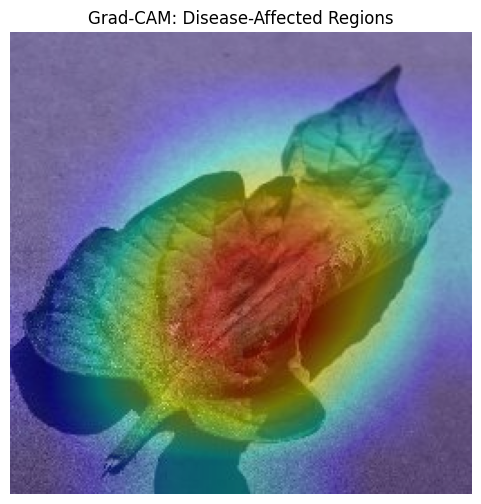


Disease detected: Tomato___Late_blight
Confidence: 92.59%

Recommended Action:
Apply systemic fungicide immediately.

Explanation:
Tomato Late blight is a disease of tomato plants. It is caused by the fungus Fusarium spp., which causes a dark, wilting, and sometimes fatal rash on the plant. The disease is caused when the plant is infected with a virus that causes the plant to become infecund. The virus causes the lesions to become rapidly spreading and dark.


In [9]:
# ===============================
# 21. UPLOAD & TEST
# ===============================
uploaded = files.upload()

for file_name in uploaded.keys():
    result = get_final_output_with_explainability(file_name)
    print("\n" + "="*60)
    print(result)
    print("="*60)
